In [1]:
import pandas as pd
df=pd.read_csv("marketing_campaign.csv")
df.describe()
# print(df.columns.tolist())   # check karen duplicate to nahi
# df_clean = df.loc[:, ~df.columns.duplicated()]  # agar hon to hata den

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
count,2240
unique,2240
top,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
freq,1


In [ ]:
"""
Module 7: Cluster Evaluation & Customer Profiling
STEP 1: Data Cleaning & Preprocessing
Dataset: Customer Personality Analysis (marketing_campaign.csv)
"""

import pandas as pd
import numpy as np

# -----------------------------------------------------
# 1. LOAD THE DATASET
# -----------------------------------------------------
# The file is tab-separated (\t), not comma-separated
df = pd.read_csv('marketing_campaign.csv', sep='\t')

print("Original shape (rows, columns):", df.shape)
print(df.head())

# -----------------------------------------------------
# 2. CHECK FOR MISSING VALUES
# -----------------------------------------------------
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
# Result: only 'Income' has 24 missing values

# -----------------------------------------------------
# 3. HANDLE MISSING INCOME VALUES
# -----------------------------------------------------
# We fill missing Income with the MEDIAN (not mean),
# because Income has extreme outliers that would distort the mean.
median_income = df['Income'].median()
df['Income'] = df['Income'].fillna(median_income)

print(f"\nFilled 24 missing Income values with median: {median_income}")

# -----------------------------------------------------
# 4. CLEAN THE 'Marital_Status' COLUMN
# -----------------------------------------------------
# Check unique categories first
print("\nMarital_Status before cleaning:")
print(df['Marital_Status'].value_counts())

# 'Alone' means the same as 'Single' -> merge them
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single'})

# 'Absurd' and 'YOLO' are joke/test entries, not real categories -> remove those rows
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

print("\nMarital_Status after cleaning:")
print(df['Marital_Status'].value_counts())

# -----------------------------------------------------
# 5. REMOVE UNREALISTIC AGE (Year_Birth) OUTLIERS
# -----------------------------------------------------
# Anyone born before 1940 would be 85+ years old in some cases up to 130+,
# which is unrealistic for this dataset -> treat as data entry errors
print("\nCustomers with Year_Birth < 1940:")
print(df[df['Year_Birth'] < 1940][['ID', 'Year_Birth']])

df = df[df['Year_Birth'] >= 1940]

# -----------------------------------------------------
# 6. REMOVE INCOME OUTLIER
# -----------------------------------------------------
# One customer has Income = 666,666 which is an obvious fake/placeholder value
print("\nIncome outlier check:")
print(df[df['Income'] > 200000][['ID', 'Income']])

df = df[df['Income'] < 200000]

# -----------------------------------------------------
# 7. DROP USELESS (CONSTANT) COLUMNS
# -----------------------------------------------------
# Z_CostContact and Z_Revenue have the SAME value for every customer
# -> they carry zero information for analysis, so we drop them
print("\nZ_CostContact unique values:", df['Z_CostContact'].unique())
print("Z_Revenue unique values:", df['Z_Revenue'].unique())

df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

# -----------------------------------------------------
# 8. FINAL CHECK
# -----------------------------------------------------
print("\nFinal shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

# -----------------------------------------------------
# 9. SAVE THE CLEANED DATASET
# -----------------------------------------------------
df.to_csv('marketing_campaign_cleaned.csv', index=False)
print("\nCleaned dataset saved as 'marketing_campaign_cleaned.csv'")

Original shape (rows, columns): (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1

In [3]:
"""
Module 7: Cluster Evaluation & Customer Profiling
STEP 2: Feature Engineering
Input: marketing_campaign_cleaned.csv (output of Step 1)
"""

import pandas as pd

# -----------------------------------------------------
# 1. LOAD THE CLEANED DATASET (from Step 1)
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_cleaned.csv')

print("Loaded shape:", df.shape)

# -----------------------------------------------------
# 2. CREATE 'Age' FROM 'Year_Birth'
# -----------------------------------------------------
# We use 2014 as reference year because this dataset's
# customer enrollment dates (Dt_Customer) are from 2012-2014.
current_year = 2014
df['Age'] = current_year - df['Year_Birth']

# -----------------------------------------------------
# 3. CREATE 'Total_Spending'
# -----------------------------------------------------
# Sum of spending across all product categories
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# -----------------------------------------------------
# 4. CREATE 'Total_Children' AND 'Family_Size'
# -----------------------------------------------------
# Total_Children = Kidhome + Teenhome (as required by the task)
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Family_Size = customer + partner (if Married/Together) + children
df['Family_Size'] = df['Marital_Status'].map({
    'Married': 2, 'Together': 2,
    'Single': 1, 'Divorced': 1, 'Widow': 1
}) + df['Total_Children']

# -----------------------------------------------------
# 5. CREATE 'Total_Purchases'
# -----------------------------------------------------
# Sum of purchases across all channels (web, catalog, store, deals)
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                  'NumStorePurchases', 'NumDealsPurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# -----------------------------------------------------
# 6. CREATE 'Total_Campaigns_Accepted'
# -----------------------------------------------------
# Sum of all 5 past campaign acceptances + the final Response
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Total_Campaigns_Accepted'] = df[campaign_cols].sum(axis=1)

# -----------------------------------------------------
# 7. CREATE 'Customer_Tenure_Days'
# -----------------------------------------------------
# How many days since the customer joined (Dt_Customer)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

# -----------------------------------------------------
# 8. FINAL CHECK
# -----------------------------------------------------
new_features = ['Age', 'Total_Spending', 'Total_Children', 'Family_Size',
                 'Total_Purchases', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']

print("\nNew features created:")
print(df[new_features].describe())

# -----------------------------------------------------
# 9. SAVE THE DATASET WITH NEW FEATURES
# -----------------------------------------------------
df.to_csv('marketing_campaign_features.csv', index=False)
print("\nSaved as 'marketing_campaign_features.csv'")
print("Final shape:", df.shape)

Loaded shape: (2232, 27)

New features created:
               Age  Total_Spending  Total_Children  Family_Size  \
count  2232.000000     2232.000000     2232.000000  2232.000000   
mean     45.111111      605.624104        0.951613     2.597670   
std      11.699288      602.123276        0.752338     0.906846   
min      18.000000        5.000000        0.000000     1.000000   
25%      37.000000       69.000000        0.000000     2.000000   
50%      44.000000      396.000000        1.000000     3.000000   
75%      55.000000     1044.250000        1.000000     3.000000   
max      74.000000     2525.000000        3.000000     5.000000   

       Total_Purchases  Total_Campaigns_Accepted  Customer_Tenure_Days  
count      2232.000000               2232.000000           2232.000000  
mean         14.864695                  0.446237            353.526882  
std           7.682142                  0.890094            202.123479  
min           0.000000                  0.000000        

In [4]:
"""
Module 7: Cluster Evaluation & Customer Profiling
STEP 2: Feature Engineering
Input: marketing_campaign_cleaned.csv (output of Step 1)
"""

import pandas as pd
import numpy as np

# -----------------------------------------------------
# 1. LOAD THE CLEANED DATASET (from Step 1)
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_cleaned.csv')

print("Shape before feature engineering:", df.shape)

# -----------------------------------------------------
# 2. CREATE 'Age' COLUMN
# -----------------------------------------------------
# The dataset is from ~2012-2014, so we calculate age relative to 2014
# (the latest year of customer enrollment in this dataset)
current_year = 2014
df['Age'] = current_year - df['Year_Birth']

print("\nAge column created. Sample stats:")
print(df['Age'].describe())

# -----------------------------------------------------
# 3. CREATE 'Total_Spending' COLUMN
# -----------------------------------------------------
# Sum of spending across all product categories
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

print("\nTotal_Spending column created. Sample stats:")
print(df['Total_Spending'].describe())

# -----------------------------------------------------
# 4. CREATE 'Total_Children' COLUMN
# -----------------------------------------------------
# Simply Kidhome (young children) + Teenhome (teenagers) at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# -----------------------------------------------------
# 5. CREATE 'Family_Size' COLUMN
# -----------------------------------------------------
# Family size = number of adults in the household + number of children
# Marital_Status tells us how many adults live in the house:
#   Married / Together -> 2 adults
#   Single / Divorced / Widow -> 1 adult
adults_map = {
    'Married': 2,
    'Together': 2,
    'Single': 1,
    'Divorced': 1,
    'Widow': 1
}
df['Adults'] = df['Marital_Status'].map(adults_map)
df['Family_Size'] = df['Adults'] + df['Total_Children']

# -----------------------------------------------------
# 6. CREATE 'Total_Purchases' COLUMN
# -----------------------------------------------------
# Sum of purchases made through every channel
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                  'NumStorePurchases', 'NumDealsPurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# -----------------------------------------------------
# 7. CREATE 'Total_Campaigns_Accepted' COLUMN
# -----------------------------------------------------
# Sum of all 5 past campaign acceptances + the final Response
# Tells us how "campaign-responsive" a customer is overall
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df['Total_Campaigns_Accepted'] = df[campaign_cols].sum(axis=1)

# -----------------------------------------------------
# 8. CREATE 'Customer_Tenure_Days' COLUMN
# -----------------------------------------------------
# How long the customer has been enrolled, based on Dt_Customer
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
reference_date = df['Dt_Customer'].max()  # most recent enrollment date in the data
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

# -----------------------------------------------------
# 9. DROP HELPER COLUMN WE NO LONGER NEED
# -----------------------------------------------------
df = df.drop(columns=['Adults'])

# -----------------------------------------------------
# 10. FINAL CHECK
# -----------------------------------------------------
new_columns = ['Age', 'Total_Spending', 'Total_Children', 'Family_Size',
               'Total_Purchases', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']

print("\nNew columns added:", new_columns)
print("\nShape after feature engineering:", df.shape)
print("\nPreview of new columns:")
print(df[new_columns].head())

# -----------------------------------------------------
# 11. SAVE THE ENGINEERED DATASET
# -----------------------------------------------------
df.to_csv('marketing_campaign_engineered.csv', index=False)
print("\nSaved as 'marketing_campaign_engineered.csv'")

Shape before feature engineering: (2232, 27)

Age column created. Sample stats:
count    2232.000000
mean       45.111111
std        11.699288
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64

Total_Spending column created. Sample stats:
count    2232.000000
mean      605.624104
std       602.123276
min         5.000000
25%        69.000000
50%       396.000000
75%      1044.250000
max      2525.000000
Name: Total_Spending, dtype: float64

New columns added: ['Age', 'Total_Spending', 'Total_Children', 'Family_Size', 'Total_Purchases', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']

Shape after feature engineering: (2232, 34)

Preview of new columns:
   Age  Total_Spending  Total_Children  Family_Size  Total_Purchases  \
0   57            1617               0            1               25   
1   60              27               2            3                6   
2   49             776               0 

In [5]:
"""
Module 7: Cluster Evaluation & Customer Profiling
STEP 3: Feature Scaling (Preparing data for clustering)
Input: marketing_campaign_engineered.csv (output of Step 2)
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# -----------------------------------------------------
# 1. LOAD THE ENGINEERED DATASET (from Step 2)
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_engineered.csv')

print("Shape:", df.shape)
print(df.columns.tolist())

# -----------------------------------------------------
# 2. ENCODE CATEGORICAL COLUMNS
# -----------------------------------------------------
# Clustering algorithms (like KMeans) only work with numbers,
# so we convert 'Education' and 'Marital_Status' into numeric codes.
le_education = LabelEncoder()
le_marital = LabelEncoder()

df['Education_Encoded'] = le_education.fit_transform(df['Education'])
df['Marital_Status_Encoded'] = le_marital.fit_transform(df['Marital_Status'])

print("\nEducation categories mapped to numbers:")
for i, category in enumerate(le_education.classes_):
    print(f"  {category} -> {i}")

print("\nMarital_Status categories mapped to numbers:")
for i, category in enumerate(le_marital.classes_):
    print(f"  {category} -> {i}")

# -----------------------------------------------------
# 3. SELECT FEATURES FOR CLUSTERING
# -----------------------------------------------------
# We choose the columns that best describe a customer's behavior:
# demographics, spending, purchase channels, and engagement.
# We do NOT include ID, Dt_Customer (raw date), or individual
# campaign columns here, since Total_Campaigns_Accepted already
# summarizes them.
cluster_features = [
    'Age', 'Income', 'Education_Encoded', 'Marital_Status_Encoded',
    'Family_Size', 'Total_Children',
    'Recency', 'Total_Spending',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth',
    'Total_Purchases', 'Total_Campaigns_Accepted',
    'Customer_Tenure_Days'
]

X = df[cluster_features].copy()

print("\nFeatures selected for clustering:", len(cluster_features))
print(X.head())

# -----------------------------------------------------
# 4. APPLY STANDARD SCALING
# -----------------------------------------------------
# StandardScaler transforms every column so that:
#   mean = 0, standard deviation = 1
# This puts all features on the same scale, which is essential
# for distance-based algorithms like KMeans.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame with the same column names
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print("\nBefore scaling (first row):")
print(X.iloc[0])

print("\nAfter scaling (first row):")
print(X_scaled_df.iloc[0])

print("\nScaled data summary (mean should be ~0, std should be ~1):")
print(X_scaled_df.describe().loc[['mean', 'std']])

# -----------------------------------------------------
# 5. SAVE THE SCALED DATA FOR CLUSTERING (STEP 4)
# -----------------------------------------------------
# We save both:
#   - the scaled features (used to actually run KMeans)
#   - the full engineered dataframe (used later to attach cluster
#     labels back onto real, human-readable values for profiling)
X_scaled_df.to_csv('marketing_campaign_scaled.csv', index=False)
df.to_csv('marketing_campaign_full.csv', index=False)

print("\nSaved 'marketing_campaign_scaled.csv' (for clustering)")
print("Saved 'marketing_campaign_full.csv' (original values + encodings, for later profiling)")

Shape: (2232, 34)
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_Spending', 'Total_Children', 'Family_Size', 'Total_Purchases', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']

Education categories mapped to numbers:
  2n Cycle -> 0
  Basic -> 1
  Graduation -> 2
  Master -> 3
  PhD -> 4

Marital_Status categories mapped to numbers:
  Divorced -> 0
  Married -> 1
  Single -> 2
  Together -> 3
  Widow -> 4

Features selected for clustering: 22
   Age   Income  Education_Encoded  Marital_Status_Encoded  Family_Size  \
0   57  58138.0                  2                       2            1   
1   60  46344

Shape of scaled data used for clustering: (2232, 22)
k=2  ->  WCSS=34803.91
k=3  ->  WCSS=31088.05
k=4  ->  WCSS=29604.80
k=5  ->  WCSS=28380.56
k=6  ->  WCSS=27387.40
k=7  ->  WCSS=26546.20
k=8  ->  WCSS=25809.80
k=9  ->  WCSS=25235.69
k=10  ->  WCSS=24719.36


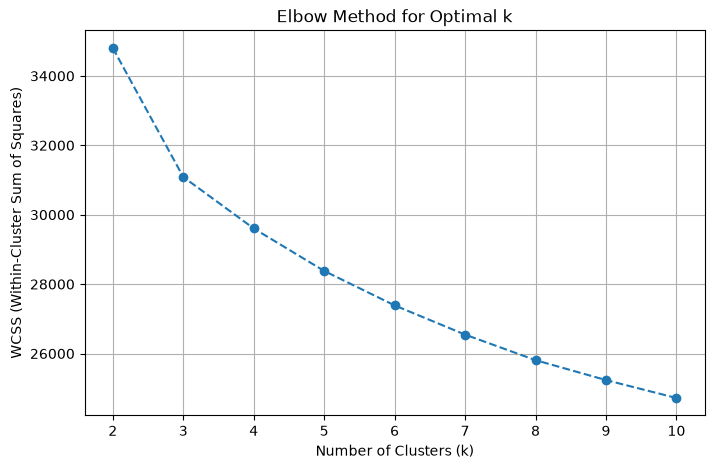


Elbow plot saved as 'elbow_method.png'
k=2  ->  Silhouette Score=0.2844
k=3  ->  Silhouette Score=0.2014
k=4  ->  Silhouette Score=0.1164
k=5  ->  Silhouette Score=0.1071
k=6  ->  Silhouette Score=0.1010
k=7  ->  Silhouette Score=0.1033
k=8  ->  Silhouette Score=0.1028
k=9  ->  Silhouette Score=0.1048
k=10  ->  Silhouette Score=0.0849


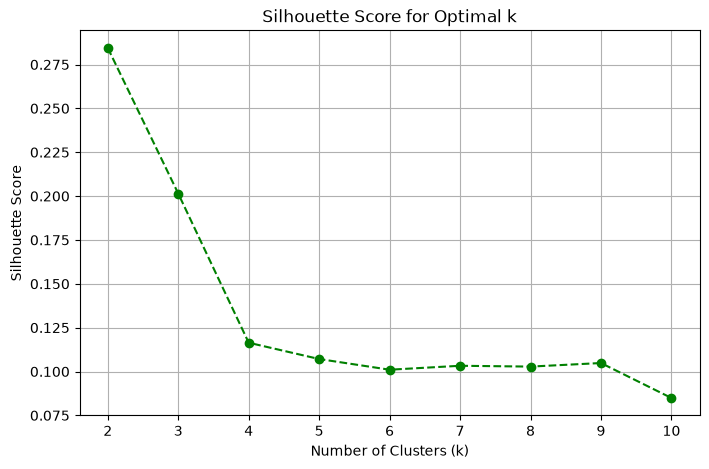


Silhouette plot saved as 'silhouette_scores.png'

Best k according to Silhouette Score: 2
NOTE: Also visually check the Elbow plot -- the chosen k should
make sense on BOTH the elbow curve and the silhouette score,
and should also make practical business sense
(too many clusters are hard to act on in marketing).


In [6]:
"""
Module 7: Cluster Evaluation & Customer Profiling
STEP 4: Finding the Optimal Number of Clusters
        (Elbow Method + Silhouette Score)
Input: marketing_campaign_scaled.csv (output of Step 3)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------------------------------
# 1. LOAD THE SCALED DATA (from Step 3)
# -----------------------------------------------------
X_scaled = pd.read_csv('marketing_campaign_scaled.csv')

print("Shape of scaled data used for clustering:", X_scaled.shape)

# -----------------------------------------------------
# 2. ELBOW METHOD
# -----------------------------------------------------
# WCSS = Within-Cluster Sum of Squares
# This measures how tightly packed the points are inside each cluster.
# As k (number of clusters) increases, WCSS always decreases.
# We look for the "elbow point" -- where the drop in WCSS starts
# slowing down significantly. That point is a good candidate for k.

wcss = []
k_range = range(2, 11)  # we test from 2 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS for this k
    print(f"k={k}  ->  WCSS={kmeans.inertia_:.2f}")

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nElbow plot saved as 'elbow_method.png'")

# -----------------------------------------------------
# 3. SILHOUETTE SCORE
# -----------------------------------------------------
# Silhouette Score tells us how well-separated the clusters are.
# Range: -1 to +1
#   Close to +1 -> clusters are well separated and distinct
#   Close to 0  -> clusters are overlapping
#   Negative    -> points may be in the wrong cluster
# We calculate this for each k and pick the k with the HIGHEST score.

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}  ->  Silhouette Score={score:.4f}")

# Plot the Silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o', linestyle='--', color='green')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSilhouette plot saved as 'silhouette_scores.png'")

# -----------------------------------------------------
# 4. RECOMMEND THE BEST k
# -----------------------------------------------------
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nBest k according to Silhouette Score: {best_k}")
print("NOTE: Also visually check the Elbow plot -- the chosen k should")
print("make sense on BOTH the elbow curve and the silhouette score,")
print("and should also make practical business sense")
print("(too many clusters are hard to act on in marketing).")

In [7]:
"""
Module 7: Cluster Evaluation & Customer Profiling
STEP 5: Running KMeans Clustering (k=4)
Input: marketing_campaign_scaled.csv (for clustering)
       marketing_campaign_full.csv (for attaching labels to real values)
"""

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------------------------------
# 1. LOAD THE SCALED DATA (used for clustering)
# -----------------------------------------------------
X_scaled = pd.read_csv('marketing_campaign_scaled.csv')

# -----------------------------------------------------
# 2. LOAD THE FULL DATA (real values, for profiling later)
# -----------------------------------------------------
df_full = pd.read_csv('marketing_campaign_full.csv')

# -----------------------------------------------------
# 3. RUN KMEANS WITH k=4
# -----------------------------------------------------
# We chose k=4 based on Step 4 (Elbow Method + Silhouette Score),
# balancing statistical quality with business usefulness --
# 4 clusters give distinct, actionable marketing segments.
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"KMeans clustering complete with k={k}")

# -----------------------------------------------------
# 4. ATTACH CLUSTER LABELS BACK TO THE FULL DATASET
# -----------------------------------------------------
# Now every customer (with their REAL, original values --
# not the scaled ones) has a 'Cluster' number: 0, 1, 2, or 3
df_full['Cluster'] = cluster_labels

# -----------------------------------------------------
# 5. CHECK CLUSTER SIZES
# -----------------------------------------------------
print("\nNumber of customers in each cluster:")
print(df_full['Cluster'].value_counts().sort_index())

print("\nPercentage of customers in each cluster:")
print((df_full['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

# -----------------------------------------------------
# 6. EVALUATE CLUSTER QUALITY
# -----------------------------------------------------
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"\nSilhouette Score for k={k}: {sil_score:.4f}")
print("(Score closer to 1 = well separated clusters;")
print(" closer to 0 = some overlap between clusters, which is")
print(" normal in real customer data since human behavior")
print(" doesn't fall into perfectly separated boxes)")

# -----------------------------------------------------
# 7. QUICK PREVIEW: AVERAGE VALUES PER CLUSTER
# -----------------------------------------------------
# This gives us a first look at what makes each cluster different
# before we do the full profiling in the next steps.
preview_cols = ['Age', 'Income', 'Total_Spending', 'Total_Purchases',
                 'Total_Campaigns_Accepted', 'Family_Size']

print("\nQuick preview -- average values per cluster:")
print(df_full.groupby('Cluster')[preview_cols].mean().round(1))

# -----------------------------------------------------
# 8. SAVE THE FINAL DATASET WITH CLUSTER LABELS
# -----------------------------------------------------
# This is the file we will use for ALL remaining activities
# (Activity 1 through Activity 7 of the original task)
df_full.to_csv('marketing_campaign_clustered.csv', index=False)
print("\nSaved 'marketing_campaign_clustered.csv'")
print("This file now has a 'Cluster' column and will be used")
print("for all remaining profiling and analysis activities.")

KMeans clustering complete with k=4

Number of customers in each cluster:
Cluster
0    575
1    462
2    555
3    640
Name: count, dtype: int64

Percentage of customers in each cluster:
Cluster
0    25.76
1    20.70
2    24.87
3    28.67
Name: proportion, dtype: float64

Silhouette Score for k=4: 0.1164
(Score closer to 1 = well separated clusters;
 closer to 0 = some overlap between clusters, which is
 normal in real customer data since human behavior
 doesn't fall into perfectly separated boxes)

Quick preview -- average values per cluster:
          Age   Income  Total_Spending  Total_Purchases  \
Cluster                                                   
0        48.6  58716.3           789.7             21.7   
1        49.9  43145.5           126.7              9.4   
2        45.5  76257.6          1399.8             20.8   
3        38.1  31103.7            97.3              7.5   

         Total_Campaigns_Accepted  Family_Size  
Cluster                                        

In [8]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 1: Cluster Statistics & Demographic Analysis
Input: marketing_campaign_clustered.csv (output of Step 5)
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# -----------------------------------------------------
# 1. LOAD THE CLUSTERED DATASET
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_clustered.csv')
print("Dataset loaded:", df.shape)
print("Clusters present:", sorted(df['Cluster'].unique()))

# -----------------------------------------------------
# 2. NUMBER OF CUSTOMERS PER CLUSTER
# -----------------------------------------------------
print("\n" + "="*60)
print("NUMBER OF CUSTOMERS PER CLUSTER")
print("="*60)
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

# -----------------------------------------------------
# 3. AVERAGE VALUE OF EVERY NUMERIC FEATURE BY CLUSTER
# -----------------------------------------------------
# This gives a full statistical fingerprint of each cluster
print("\n" + "="*60)
print("AVERAGE VALUE OF EVERY NUMERIC FEATURE, PER CLUSTER")
print("="*60)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['ID', 'Cluster']]

cluster_stats_table = df.groupby('Cluster')[numeric_cols].mean().round(2)
print(cluster_stats_table)

# Save this as the "Cluster Statistics Table" deliverable
cluster_stats_table.to_csv('activity1_cluster_statistics_table.csv')
print("\nSaved 'activity1_cluster_statistics_table.csv'")

# -----------------------------------------------------
# 4. COMPARE AGE ACROSS CLUSTERS
# -----------------------------------------------------
print("\n" + "="*60)
print("AGE COMPARISON ACROSS CLUSTERS")
print("="*60)
print(df.groupby('Cluster')['Age'].agg(['mean', 'median', 'min', 'max', 'std']).round(1))

# -----------------------------------------------------
# 5. COMPARE INCOME ACROSS CLUSTERS
# -----------------------------------------------------
print("\n" + "="*60)
print("INCOME COMPARISON ACROSS CLUSTERS")
print("="*60)
print(df.groupby('Cluster')['Income'].agg(['mean', 'median', 'min', 'max', 'std']).round(2))

# -----------------------------------------------------
# 6. COMPARE EDUCATION LEVELS ACROSS CLUSTERS
# -----------------------------------------------------
print("\n" + "="*60)
print("EDUCATION DISTRIBUTION ACROSS CLUSTERS (%)")
print("="*60)
education_dist = pd.crosstab(df['Cluster'], df['Education'], normalize='index') * 100
print(education_dist.round(1))

# -----------------------------------------------------
# 7. COMPARE MARITAL STATUS DISTRIBUTION
# -----------------------------------------------------
print("\n" + "="*60)
print("MARITAL STATUS DISTRIBUTION ACROSS CLUSTERS (%)")
print("="*60)
marital_dist = pd.crosstab(df['Cluster'], df['Marital_Status'], normalize='index') * 100
print(marital_dist.round(1))

# -----------------------------------------------------
# 8. COMPARE HOUSEHOLD SIZE (Family_Size)
# -----------------------------------------------------
print("\n" + "="*60)
print("FAMILY SIZE COMPARISON ACROSS CLUSTERS")
print("="*60)
print(df.groupby('Cluster')['Family_Size'].agg(['mean', 'median', 'min', 'max']).round(2))

# -----------------------------------------------------
# 9. COMPARE NUMBER OF CHILDREN (Kidhome + Teenhome)
# -----------------------------------------------------
print("\n" + "="*60)
print("NUMBER OF CHILDREN (Kidhome + Teenhome) ACROSS CLUSTERS")
print("="*60)
print(df.groupby('Cluster')['Total_Children'].agg(['mean', 'median', 'min', 'max']).round(2))

# -----------------------------------------------------
# 10. BUILD THE FULL DEMOGRAPHIC COMPARISON TABLE (DELIVERABLE)
# -----------------------------------------------------
# This combines age, income, education (most common), marital status
# (most common), family size, and children into ONE summary table --
# exactly what the task calls the "Demographic Comparison Report"
demographic_summary = df.groupby('Cluster').agg(
    Num_Customers=('ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Most_Common_Education=('Education', lambda x: x.mode()[0]),
    Most_Common_Marital_Status=('Marital_Status', lambda x: x.mode()[0]),
    Avg_Family_Size=('Family_Size', 'mean'),
    Avg_Children=('Total_Children', 'mean')
).round(2)

print("\n" + "="*60)
print("DEMOGRAPHIC COMPARISON REPORT (Deliverable)")
print("="*60)
print(demographic_summary)

demographic_summary.to_csv('activity1_demographic_comparison_report.csv')
print("\nSaved 'activity1_demographic_comparison_report.csv'")

Dataset loaded: (2232, 37)
Clusters present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

NUMBER OF CUSTOMERS PER CLUSTER
Cluster
0    575
1    462
2    555
3    640
Name: count, dtype: int64

AVERAGE VALUE OF EVERY NUMERIC FEATURE, PER CLUSTER
         Year_Birth    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                                                                                                                                
0           1965.36  58716.29     0.24      0.87    47.87    489.75      24.94           149.34            32.98             26.78         65.93               3.73             6.67   
1           1964.06  43145.53     0.89      1.00    50.95     73.63       3.65            26.58             5.32              3.61         13.90               2.65             2.43   
2         

In [9]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 2: Spending Behavior Analysis
Input: marketing_campaign_clustered.csv
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# -----------------------------------------------------
# 1. LOAD THE CLUSTERED DATASET
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_clustered.csv')

product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# -----------------------------------------------------
# 2. COMPARE TOTAL SPENDING ACROSS CLUSTERS
# -----------------------------------------------------
print("="*60)
print("TOTAL SPENDING COMPARISON ACROSS CLUSTERS")
print("="*60)
total_spending_by_cluster = df.groupby('Cluster')['Total_Spending'].agg(
    ['mean', 'median', 'min', 'max', 'sum']).round(2)
print(total_spending_by_cluster)

# -----------------------------------------------------
# 3. COMPARE SPENDING ON EACH PRODUCT CATEGORY
# -----------------------------------------------------
print("\n" + "="*60)
print("AVERAGE SPENDING PER PRODUCT CATEGORY, BY CLUSTER")
print("="*60)
product_spending_by_cluster = df.groupby('Cluster')[product_cols].mean().round(2)
print(product_spending_by_cluster)

# Save this as the "Spending Comparison Report" deliverable
product_spending_by_cluster.to_csv('activity2_spending_comparison_report.csv')
print("\nSaved 'activity2_spending_comparison_report.csv'")

# -----------------------------------------------------
# 4. IDENTIFY HIGHEST AND LOWEST SPENDING CLUSTERS
# -----------------------------------------------------
avg_spending_by_cluster = df.groupby('Cluster')['Total_Spending'].mean()
highest_cluster = avg_spending_by_cluster.idxmax()
lowest_cluster = avg_spending_by_cluster.idxmin()

print("\n" + "="*60)
print("HIGHEST vs LOWEST SPENDING CLUSTER")
print("="*60)
print(f"Highest spending cluster: Cluster {highest_cluster} "
      f"(avg spending = {avg_spending_by_cluster[highest_cluster]:.2f})")
print(f"Lowest spending cluster:  Cluster {lowest_cluster} "
      f"(avg spending = {avg_spending_by_cluster[lowest_cluster]:.2f})")

# -----------------------------------------------------
# 5. IDENTIFY WHICH PRODUCT EACH CLUSTER PREFERS MOST
# -----------------------------------------------------
# For each cluster, which product category gets the most spending?
print("\n" + "="*60)
print("TOP PREFERRED PRODUCT CATEGORY PER CLUSTER")
print("="*60)
top_product_per_cluster = product_spending_by_cluster.idxmax(axis=1)
print(top_product_per_cluster)

# -----------------------------------------------------
# 6. IDENTIFY PREMIUM PRODUCT BUYERS
# -----------------------------------------------------
# We define "premium buyers" as customers spending above the
# overall average on the higher-value categories: Wine, Meat, and Gold
premium_threshold_wine = df['MntWines'].mean()
premium_threshold_meat = df['MntMeatProducts'].mean()
premium_threshold_gold = df['MntGoldProds'].mean()

df['Is_Premium_Buyer'] = (
    (df['MntWines'] > premium_threshold_wine) &
    (df['MntMeatProducts'] > premium_threshold_meat) &
    (df['MntGoldProds'] > premium_threshold_gold)
)

print("\n" + "="*60)
print("PREMIUM PRODUCT BUYERS (spending above average on Wine, Meat & Gold)")
print("="*60)
premium_by_cluster = df.groupby('Cluster')['Is_Premium_Buyer'].sum()
premium_pct_by_cluster = (df.groupby('Cluster')['Is_Premium_Buyer'].mean() * 100).round(1)
print("Count of premium buyers per cluster:")
print(premium_by_cluster)
print("\nPercentage of premium buyers per cluster:")
print(premium_pct_by_cluster)

# -----------------------------------------------------
# 7. IDENTIFY BUDGET-CONSCIOUS CUSTOMERS
# -----------------------------------------------------
# Budget-conscious = low total spending BUT relatively high use
# of deal/discount purchases (NumDealsPurchases)
median_spending = df['Total_Spending'].median()
median_deals = df['NumDealsPurchases'].median()

df['Is_Budget_Conscious'] = (
    (df['Total_Spending'] < median_spending) &
    (df['NumDealsPurchases'] >= median_deals)
)

print("\n" + "="*60)
print("BUDGET-CONSCIOUS CUSTOMERS (low spending, high deal usage)")
print("="*60)
budget_by_cluster = df.groupby('Cluster')['Is_Budget_Conscious'].sum()
budget_pct_by_cluster = (df.groupby('Cluster')['Is_Budget_Conscious'].mean() * 100).round(1)
print("Count of budget-conscious customers per cluster:")
print(budget_by_cluster)
print("\nPercentage of budget-conscious customers per cluster:")
print(budget_pct_by_cluster)

# -----------------------------------------------------
# 8. PRODUCT PREFERENCE SUMMARY (DELIVERABLE)
# -----------------------------------------------------
# Combines everything into one clean summary table
preference_summary = product_spending_by_cluster.copy()
preference_summary['Total_Spending'] = df.groupby('Cluster')['Total_Spending'].mean().round(2)
preference_summary['Top_Product'] = top_product_per_cluster
preference_summary['Premium_Buyers_%'] = premium_pct_by_cluster
preference_summary['Budget_Conscious_%'] = budget_pct_by_cluster

print("\n" + "="*60)
print("PRODUCT PREFERENCE SUMMARY (Deliverable)")
print("="*60)
print(preference_summary)

preference_summary.to_csv('activity2_product_preference_summary.csv')
print("\nSaved 'activity2_product_preference_summary.csv'")

TOTAL SPENDING COMPARISON ACROSS CLUSTERS
            mean  median  min   max     sum
Cluster                                    
0         789.72   731.0  277  1829  454088
1         126.69    81.0    8   459   58531
2        1399.77  1376.0  421  2525  776871
3          97.29    63.5    5   467   62263

AVERAGE SPENDING PER PRODUCT CATEGORY, BY CLUSTER
         MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds
Cluster                                                                                       
0          489.75      24.94           149.34            32.98             26.78         65.93
1           73.63       3.65            26.58             5.32              3.61         13.90
2          615.89      69.07           467.18           100.47             70.72         76.43
3           33.17       6.59            23.78             9.89              6.51         17.34

Saved 'activity2_spending_comparison_report.csv'

HIGHEST vs LOWEST SPEN

In [10]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 3: Shopping Channel & Customer Engagement Analysis
Input: marketing_campaign_clustered.csv
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# -----------------------------------------------------
# 1. LOAD THE CLUSTERED DATASET
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_clustered.csv')

channel_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases', 'NumDealsPurchases']

# -----------------------------------------------------
# 2. COMPARE PURCHASES ACROSS EACH CHANNEL
# -----------------------------------------------------
print("="*60)
print("AVERAGE PURCHASES PER CHANNEL, BY CLUSTER")
print("="*60)
channel_by_cluster = df.groupby('Cluster')[channel_cols].mean().round(2)
print(channel_by_cluster)

# Save this as the "Channel Preference Report" deliverable
channel_by_cluster.to_csv('activity3_channel_preference_report.csv')
print("\nSaved 'activity3_channel_preference_report.csv'")

# -----------------------------------------------------
# 3. COMPARE WEBSITE VISITS PER MONTH
# -----------------------------------------------------
print("\n" + "="*60)
print("WEBSITE VISITS PER MONTH, BY CLUSTER")
print("="*60)
print(df.groupby('Cluster')['NumWebVisitsMonth'].agg(['mean', 'median', 'min', 'max']).round(2))

# -----------------------------------------------------
# 4. COMPARE RECENCY (days since last purchase)
# -----------------------------------------------------
# Lower Recency = more recently active customer
print("\n" + "="*60)
print("RECENCY (days since last purchase), BY CLUSTER")
print("="*60)
print(df.groupby('Cluster')['Recency'].agg(['mean', 'median', 'min', 'max']).round(2))

# -----------------------------------------------------
# 5. IDENTIFY DIGITAL-FIRST CUSTOMERS
# -----------------------------------------------------
# Digital-first = Web purchases are their dominant channel
# (Web purchases + Web visits are higher than Catalog and Store combined)
df['Is_Digital_First'] = (
    df['NumWebPurchases'] > (df['NumCatalogPurchases'] + df['NumStorePurchases']) / 2
) & (df['NumWebVisitsMonth'] > df['NumWebVisitsMonth'].median())

print("\n" + "="*60)
print("DIGITAL-FIRST CUSTOMERS (high web purchases + high web visits)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Is_Digital_First'].mean() * 100).round(1))

# -----------------------------------------------------
# 6. IDENTIFY STORE-ORIENTED CUSTOMERS
# -----------------------------------------------------
# Store purchases are their dominant channel
df['Is_Store_Oriented'] = (
    df['NumStorePurchases'] > df['NumWebPurchases']
) & (df['NumStorePurchases'] > df['NumCatalogPurchases'])

print("\n" + "="*60)
print("STORE-ORIENTED CUSTOMERS (store is their main channel)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Is_Store_Oriented'].mean() * 100).round(1))

# -----------------------------------------------------
# 7. IDENTIFY CATALOG-ORIENTED CUSTOMERS
# -----------------------------------------------------
# Catalog purchases are their dominant channel
df['Is_Catalog_Oriented'] = (
    df['NumCatalogPurchases'] > df['NumWebPurchases']
) & (df['NumCatalogPurchases'] > df['NumStorePurchases'])

print("\n" + "="*60)
print("CATALOG-ORIENTED CUSTOMERS (catalog is their main channel)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Is_Catalog_Oriented'].mean() * 100).round(1))

# -----------------------------------------------------
# 8. IDENTIFY DEAL-SEEKING CUSTOMERS
# -----------------------------------------------------
# Deal-seeking = above-average use of deal/discount purchases
df['Is_Deal_Seeking'] = df['NumDealsPurchases'] > df['NumDealsPurchases'].mean()

print("\n" + "="*60)
print("DEAL-SEEKING CUSTOMERS (above-average deal purchases)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Is_Deal_Seeking'].mean() * 100).round(1))

# -----------------------------------------------------
# 9. IDENTIFY ACTIVE vs INACTIVE CUSTOMER SEGMENTS
# -----------------------------------------------------
# Active = recent purchase (low Recency, below the overall median)
# Inactive = has not purchased in a long time (high Recency, above median)
recency_median = df['Recency'].median()
df['Engagement_Status'] = np.where(df['Recency'] <= recency_median, 'Active', 'Inactive')

print("\n" + "="*60)
print("ACTIVE vs INACTIVE CUSTOMERS, BY CLUSTER (%)")
print("="*60)
engagement_dist = pd.crosstab(df['Cluster'], df['Engagement_Status'], normalize='index') * 100
print(engagement_dist.round(1))

# -----------------------------------------------------
# 10. CUSTOMER ENGAGEMENT REPORT (DELIVERABLE)
# -----------------------------------------------------
engagement_report = df.groupby('Cluster').agg(
    Avg_Web_Purchases=('NumWebPurchases', 'mean'),
    Avg_Catalog_Purchases=('NumCatalogPurchases', 'mean'),
    Avg_Store_Purchases=('NumStorePurchases', 'mean'),
    Avg_Deal_Purchases=('NumDealsPurchases', 'mean'),
    Avg_Web_Visits_Month=('NumWebVisitsMonth', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Digital_First_Pct=('Is_Digital_First', lambda x: round(x.mean() * 100, 1)),
    Store_Oriented_Pct=('Is_Store_Oriented', lambda x: round(x.mean() * 100, 1)),
    Catalog_Oriented_Pct=('Is_Catalog_Oriented', lambda x: round(x.mean() * 100, 1)),
    Deal_Seeking_Pct=('Is_Deal_Seeking', lambda x: round(x.mean() * 100, 1)),
    Active_Pct=('Engagement_Status', lambda x: round((x == 'Active').mean() * 100, 1))
).round(2)

print("\n" + "="*60)
print("CUSTOMER ENGAGEMENT REPORT (Deliverable)")
print("="*60)
print(engagement_report)

engagement_report.to_csv('activity3_customer_engagement_report.csv')
print("\nSaved 'activity3_customer_engagement_report.csv'")

AVERAGE PURCHASES PER CHANNEL, BY CLUSTER
         NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumDealsPurchases
Cluster                                                                            
0                   6.67                 3.27               8.05               3.73
1                   2.43                 0.74               3.58               2.65
2                   5.07                 6.08               8.35               1.27
3                   2.11                 0.54               3.15               1.74

Saved 'activity3_channel_preference_report.csv'

WEBSITE VISITS PER MONTH, BY CLUSTER
         mean  median  min  max
Cluster                        
0        5.74     6.0    0   10
1        6.05     6.0    0   20
2        2.75     2.0    0    9
3        6.65     7.0    0   20

RECENCY (days since last purchase), BY CLUSTER
          mean  median  min  max
Cluster                         
0        47.87    48.0    0   99
1        50.95    51.0    0 

In [11]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 4: Marketing Campaign Analysis
Input: marketing_campaign_clustered.csv
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# -----------------------------------------------------
# 1. LOAD THE CLUSTERED DATASET
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_clustered.csv')

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# -----------------------------------------------------
# 2. ANALYZE EACH CAMPAIGN'S ACCEPTANCE RATE, BY CLUSTER
# -----------------------------------------------------
# Each column is 0/1, so the MEAN directly gives the acceptance
# rate as a percentage (e.g. 0.25 = 25% accepted that campaign)
print("="*60)
print("CAMPAIGN ACCEPTANCE RATE (%) PER CLUSTER")
print("="*60)
campaign_acceptance = (df.groupby('Cluster')[campaign_cols].mean() * 100).round(1)
campaign_acceptance.columns = ['Cmp1_%', 'Cmp2_%', 'Cmp3_%', 'Cmp4_%', 'Cmp5_%', 'Final_Response_%']
print(campaign_acceptance)

# Save this as the "Campaign Response Comparison" deliverable
campaign_acceptance.to_csv('activity4_campaign_response_comparison.csv')
print("\nSaved 'activity4_campaign_response_comparison.csv'")

# -----------------------------------------------------
# 3. ANALYZE EACH CAMPAIGN INDIVIDUALLY (OVERALL + BY CLUSTER)
# -----------------------------------------------------
print("\n" + "="*60)
print("INDIVIDUAL CAMPAIGN BREAKDOWN")
print("="*60)
for cmp in campaign_cols:
    overall_rate = df[cmp].mean() * 100
    print(f"\n{cmp} -- Overall acceptance rate: {overall_rate:.1f}%")
    print(f"  By cluster: {dict((df.groupby('Cluster')[cmp].mean() * 100).round(1))}")

# -----------------------------------------------------
# 4. ANALYZE CUSTOMER COMPLAINT RATES
# -----------------------------------------------------
print("\n" + "="*60)
print("COMPLAINT RATE (%) PER CLUSTER")
print("="*60)
complaint_rate = (df.groupby('Cluster')['Complain'].mean() * 100).round(2)
print(complaint_rate)
print(f"\nOverall complaint rate: {(df['Complain'].mean() * 100):.2f}%")

# -----------------------------------------------------
# 5. IDENTIFY CAMPAIGN-RESPONSIVE CUSTOMERS
# -----------------------------------------------------
# We already built 'Total_Campaigns_Accepted' in Step 2
# (sum of all 5 past campaigns + the final Response, so it ranges 0-6)
# Campaign-responsive = accepted 2 or more campaigns
df['Is_Campaign_Responsive'] = df['Total_Campaigns_Accepted'] >= 2

print("\n" + "="*60)
print("CAMPAIGN-RESPONSIVE CUSTOMERS (accepted 2+ campaigns)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Is_Campaign_Responsive'].mean() * 100).round(1))

# -----------------------------------------------------
# 6. IDENTIFY MARKETING-RESISTANT CUSTOMERS
# -----------------------------------------------------
# Marketing-resistant = accepted ZERO campaigns, ever
df['Is_Marketing_Resistant'] = df['Total_Campaigns_Accepted'] == 0

print("\n" + "="*60)
print("MARKETING-RESISTANT CUSTOMERS (accepted 0 campaigns)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Is_Marketing_Resistant'].mean() * 100).round(1))

# -----------------------------------------------------
# 7. IDENTIFY CUSTOMERS REQUIRING RE-ENGAGEMENT
# -----------------------------------------------------
# Needs re-engagement = marketing-resistant (0 campaigns accepted)
# AND has not purchased recently (Recency above the median)
# -> these customers are both unresponsive AND going inactive
recency_median = df['Recency'].median()
df['Needs_ReEngagement'] = (
    (df['Total_Campaigns_Accepted'] == 0) &
    (df['Recency'] > recency_median)
)

print("\n" + "="*60)
print("CUSTOMERS REQUIRING RE-ENGAGEMENT (unresponsive + inactive)")
print("="*60)
print("Percentage per cluster:")
print((df.groupby('Cluster')['Needs_ReEngagement'].mean() * 100).round(1))

# -----------------------------------------------------
# 8. CAMPAIGN EFFECTIVENESS REPORT (DELIVERABLE)
# -----------------------------------------------------
campaign_effectiveness = df.groupby('Cluster').agg(
    Avg_Campaigns_Accepted=('Total_Campaigns_Accepted', 'mean'),
    Final_Response_Rate_Pct=('Response', lambda x: round(x.mean() * 100, 1)),
    Complaint_Rate_Pct=('Complain', lambda x: round(x.mean() * 100, 2)),
    Campaign_Responsive_Pct=('Is_Campaign_Responsive', lambda x: round(x.mean() * 100, 1)),
    Marketing_Resistant_Pct=('Is_Marketing_Resistant', lambda x: round(x.mean() * 100, 1)),
    Needs_ReEngagement_Pct=('Needs_ReEngagement', lambda x: round(x.mean() * 100, 1))
).round(2)

print("\n" + "="*60)
print("CAMPAIGN EFFECTIVENESS REPORT (Deliverable)")
print("="*60)
print(campaign_effectiveness)

campaign_effectiveness.to_csv('activity4_campaign_effectiveness_report.csv')
print("\nSaved 'activity4_campaign_effectiveness_report.csv'")

# -----------------------------------------------------
# 9. MARKETING INSIGHTS REPORT (DELIVERABLE - text summary)
# -----------------------------------------------------
most_responsive_cluster = campaign_effectiveness['Avg_Campaigns_Accepted'].idxmax()
most_resistant_cluster = campaign_effectiveness['Marketing_Resistant_Pct'].idxmax()

print("\n" + "="*60)
print("MARKETING INSIGHTS (Deliverable)")
print("="*60)
print(f"Most campaign-responsive cluster: Cluster {most_responsive_cluster} "
      f"(avg {campaign_effectiveness.loc[most_responsive_cluster, 'Avg_Campaigns_Accepted']:.2f} campaigns accepted)")
print(f"Most marketing-resistant cluster: Cluster {most_resistant_cluster} "
      f"({campaign_effectiveness.loc[most_resistant_cluster, 'Marketing_Resistant_Pct']:.1f}% never accepted a campaign)")

CAMPAIGN ACCEPTANCE RATE (%) PER CLUSTER
         Cmp1_%  Cmp2_%  Cmp3_%  Cmp4_%  Cmp5_%  Final_Response_%
Cluster                                                          
0           3.8     1.9     7.1    13.0     2.6              13.0
1           0.4     0.4     5.4     3.2     0.0               6.1
2          21.3     3.1     8.5    13.2    26.3              29.0
3           0.2     0.0     7.8     0.6     0.0              10.6

Saved 'activity4_campaign_response_comparison.csv'

INDIVIDUAL CAMPAIGN BREAKDOWN

AcceptedCmp1 -- Overall acceptance rate: 6.4%
  By cluster: {0: np.float64(3.8), 1: np.float64(0.4), 2: np.float64(21.3), 3: np.float64(0.2)}

AcceptedCmp2 -- Overall acceptance rate: 1.3%
  By cluster: {0: np.float64(1.9), 1: np.float64(0.4), 2: np.float64(3.1), 3: np.float64(0.0)}

AcceptedCmp3 -- Overall acceptance rate: 7.3%
  By cluster: {0: np.float64(7.1), 1: np.float64(5.4), 2: np.float64(8.5), 3: np.float64(7.8)}

AcceptedCmp4 -- Overall acceptance rate: 7.5%
  By c

In [1]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 4: Marketing Campaign Analysis
Input: marketing_campaign_clustered.csv
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('marketing_campaign_clustered.csv')

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# -----------------------------------------------------
# 2. ANALYZE EACH CAMPAIGN'S ACCEPTANCE RATE, BY CLUSTER
# -----------------------------------------------------
print("="*60)
print("CAMPAIGN ACCEPTANCE RATE (%) PER CLUSTER")
print("="*60)
campaign_acceptance = (df.groupby('Cluster')[campaign_cols].mean() * 100).round(1)
campaign_acceptance.columns = ['Cmp1_%', 'Cmp2_%', 'Cmp3_%', 'Cmp4_%', 'Cmp5_%', 'Final_Response_%']
print(campaign_acceptance)

campaign_acceptance.to_csv('activity4_campaign_response_comparison.csv')

# -----------------------------------------------------
# 3. ANALYZE EACH CAMPAIGN INDIVIDUALLY
# -----------------------------------------------------
for cmp in campaign_cols:
    overall_rate = df[cmp].mean() * 100
    print(f"\n{cmp} -- Overall acceptance rate: {overall_rate:.1f}%")
    print(f"  By cluster: {dict((df.groupby('Cluster')[cmp].mean() * 100).round(1))}")

# -----------------------------------------------------
# 4. ANALYZE CUSTOMER COMPLAINT RATES
# -----------------------------------------------------
complaint_rate = (df.groupby('Cluster')['Complain'].mean() * 100).round(2)
print(complaint_rate)

# -----------------------------------------------------
# 5. IDENTIFY CAMPAIGN-RESPONSIVE CUSTOMERS
# -----------------------------------------------------
# Campaign-responsive = accepted 2 or more campaigns (out of 6 total chances)
df['Is_Campaign_Responsive'] = df['Total_Campaigns_Accepted'] >= 2
print((df.groupby('Cluster')['Is_Campaign_Responsive'].mean() * 100).round(1))

# -----------------------------------------------------
# 6. IDENTIFY MARKETING-RESISTANT CUSTOMERS
# -----------------------------------------------------
# Marketing-resistant = accepted ZERO campaigns, ever
df['Is_Marketing_Resistant'] = df['Total_Campaigns_Accepted'] == 0
print((df.groupby('Cluster')['Is_Marketing_Resistant'].mean() * 100).round(1))

# -----------------------------------------------------
# 7. IDENTIFY CUSTOMERS REQUIRING RE-ENGAGEMENT
# -----------------------------------------------------
# Needs re-engagement = resistant AND inactive (high Recency)
recency_median = df['Recency'].median()
df['Needs_ReEngagement'] = (
    (df['Total_Campaigns_Accepted'] == 0) &
    (df['Recency'] > recency_median)
)
print((df.groupby('Cluster')['Needs_ReEngagement'].mean() * 100).round(1))

# -----------------------------------------------------
# 8. CAMPAIGN EFFECTIVENESS REPORT (DELIVERABLE)
# -----------------------------------------------------
campaign_effectiveness = df.groupby('Cluster').agg(
    Avg_Campaigns_Accepted=('Total_Campaigns_Accepted', 'mean'),
    Final_Response_Rate_Pct=('Response', lambda x: round(x.mean() * 100, 1)),
    Complaint_Rate_Pct=('Complain', lambda x: round(x.mean() * 100, 2)),
    Campaign_Responsive_Pct=('Is_Campaign_Responsive', lambda x: round(x.mean() * 100, 1)),
    Marketing_Resistant_Pct=('Is_Marketing_Resistant', lambda x: round(x.mean() * 100, 1)),
    Needs_ReEngagement_Pct=('Needs_ReEngagement', lambda x: round(x.mean() * 100, 1))
).round(2)

print(campaign_effectiveness)
campaign_effectiveness.to_csv('activity4_campaign_effectiveness_report.csv')

# -----------------------------------------------------
# 9. MARKETING INSIGHTS REPORT (DELIVERABLE)
# -----------------------------------------------------
most_responsive_cluster = campaign_effectiveness['Avg_Campaigns_Accepted'].idxmax()
most_resistant_cluster = campaign_effectiveness['Marketing_Resistant_Pct'].idxmax()

print(f"Most campaign-responsive cluster: Cluster {most_responsive_cluster}")
print(f"Most marketing-resistant cluster: Cluster {most_resistant_cluster}")

CAMPAIGN ACCEPTANCE RATE (%) PER CLUSTER
         Cmp1_%  Cmp2_%  Cmp3_%  Cmp4_%  Cmp5_%  Final_Response_%
Cluster                                                          
0           3.8     1.9     7.1    13.0     2.6              13.0
1           0.4     0.4     5.4     3.2     0.0               6.1
2          21.3     3.1     8.5    13.2    26.3              29.0
3           0.2     0.0     7.8     0.6     0.0              10.6

AcceptedCmp1 -- Overall acceptance rate: 6.4%
  By cluster: {0: np.float64(3.8), 1: np.float64(0.4), 2: np.float64(21.3), 3: np.float64(0.2)}

AcceptedCmp2 -- Overall acceptance rate: 1.3%
  By cluster: {0: np.float64(1.9), 1: np.float64(0.4), 2: np.float64(3.1), 3: np.float64(0.0)}

AcceptedCmp3 -- Overall acceptance rate: 7.3%
  By cluster: {0: np.float64(7.1), 1: np.float64(5.4), 2: np.float64(8.5), 3: np.float64(7.8)}

AcceptedCmp4 -- Overall acceptance rate: 7.5%
  By cluster: {0: np.float64(13.0), 1: np.float64(3.2), 2: np.float64(13.2), 3: np.float6

In [2]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 5: Business Segmentation & Cluster Naming
Input: marketing_campaign_clustered.csv
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

df = pd.read_csv('marketing_campaign_clustered.csv')

# -----------------------------------------------------
# 2. BUILD ONE COMBINED SUMMARY (all key metrics together)
# -----------------------------------------------------
combined_summary = df.groupby('Cluster').agg(
    Num_Customers=('ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Family_Size=('Family_Size', 'mean'),
    Avg_Children=('Total_Children', 'mean'),
    Avg_Total_Spending=('Total_Spending', 'mean'),
    Avg_Total_Purchases=('Total_Purchases', 'mean'),
    Avg_Web_Visits=('NumWebVisitsMonth', 'mean'),
    Avg_Store_Purchases=('NumStorePurchases', 'mean'),
    Avg_Catalog_Purchases=('NumCatalogPurchases', 'mean'),
    Avg_Deal_Purchases=('NumDealsPurchases', 'mean'),
    Avg_Campaigns_Accepted=('Total_Campaigns_Accepted', 'mean'),
    Response_Rate=('Response', 'mean'),
).round(2)

print(combined_summary.T)

# -----------------------------------------------------
# 3. ASSIGN BUSINESS NAMES BASED ON THE DATA
# -----------------------------------------------------
# Cluster 0: Mid-high income, moderate family, HIGHEST deal usage (3.73)
#            -> "Value-Conscious Family Shoppers"
# Cluster 1: Largest family (3.61), most children (1.89), lowest response (6%)
#            -> "Discount-Driven Families"
# Cluster 2: Highest income, spending, campaign acceptance, response
#            -> "Premium Loyal Customers"
# Cluster 3: Youngest, lowest income/spending, most web visits
#            -> "Young Digital Low-Spenders"

cluster_names = {
    0: 'Value-Conscious Family Shoppers',
    1: 'Discount-Driven Families',
    2: 'Premium Loyal Customers',
    3: 'Young Digital Low-Spenders'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

for cluster_id, name in cluster_names.items():
    print(f"Cluster {cluster_id}  ->  {name}")

# -----------------------------------------------------
# 4. JUSTIFICATION FOR EACH CLUSTER NAME (DELIVERABLE)
# -----------------------------------------------------
justifications = {
    0: (
        "Value-Conscious Family Shoppers: This group has a solid mid-to-high "
        "income (avg 58,716) and a moderate family size (2.78, with 1.11 "
        "children on average). What sets them apart is their HIGHEST use of "
        "deal/discount purchases (3.73 avg) of all clusters, combined with "
        "healthy overall spending (789.72) -- they buy regularly but actively "
        "look for discounts while doing so."
    ),
    1: (
        "Discount-Driven Families: This is the largest-family segment "
        "(3.61 members, 1.89 children -- both the highest of any cluster), "
        "but with lower income (43,145) and the lowest total spending among "
        "family clusters (126.69). They show the lowest campaign response "
        "(6.1%) and are largely marketing-resistant (86.1%), suggesting "
        "budget constraints from having the most dependents at home."
    ),
    2: (
        "Premium Loyal Customers: This segment stands out on every "
        "high-value metric -- the highest income (76,257), highest total "
        "spending (1,399.77, nearly double the next cluster), highest "
        "campaign acceptance (1.01 avg campaigns) and highest final "
        "response rate (29%). They have the smallest families (1.79), "
        "prefer catalog and in-store shopping over the web, and have the "
        "lowest complaint rate -- clear signs of a loyal, high-value segment."
    ),
    3: (
        "Young Digital Low-Spenders: The youngest segment by far (avg age "
        "38 vs 45-50 for others) with the lowest income (31,103) and lowest "
        "total spending (97.29) of all clusters. They visit the website the "
        "most often (6.65 visits/month, the highest), showing digital "
        "curiosity, but this doesn't yet convert into significant purchases -- "
        "likely early-career customers still building spending power."
    )
}

for cluster_id, name in cluster_names.items():
    print(f"\n--- Cluster {cluster_id}: {name} ---")
    print(justifications[cluster_id])

# -----------------------------------------------------
# 5. COMMERCIAL USEFULNESS OF EACH SEGMENT
# -----------------------------------------------------
commercial_value = {
    0: "Medium-High -- reliable spenders who respond well to discounts; "
       "good target for loyalty/deal programs.",
    1: "Low-Medium -- large customer base but low individual value; "
       "best served with budget-friendly, high-volume offers.",
    2: "Highest -- smallest group but generates the most revenue per "
       "customer and responds best to campaigns; top priority segment.",
    3: "Medium (Growth Potential) -- currently low value, but high digital "
       "engagement suggests strong potential if nurtured over time."
}

for cluster_id, name in cluster_names.items():
    print(f"\nCluster {cluster_id} ({name}): {commercial_value[cluster_id]}")

# -----------------------------------------------------
# 6. RECOMMENDED MARKETING STRATEGY PER CLUSTER (DELIVERABLE)
# -----------------------------------------------------
marketing_strategy = {
    0: "Offer bundle deals and loyalty discounts; they already respond to "
       "deals, so reward repeat purchases to increase spending further.",
    1: "Focus on affordable family-sized bundles and budget deals; keep "
       "marketing simple and value-focused since campaign response is low.",
    2: "Prioritize this group with premium/early-access offers, personalized "
       "catalogs, and loyalty rewards; protect this high-value relationship.",
    3: "Use digital channels (email, social, app) heavily since they browse "
       "often; introduce first-purchase incentives to convert browsing "
       "into buying."
}

for cluster_id, name in cluster_names.items():
    print(f"\nCluster {cluster_id} ({name}):")
    print(f"  {marketing_strategy[cluster_id]}")

# -----------------------------------------------------
# 7. SAVE EVERYTHING AS DELIVERABLES
# -----------------------------------------------------
combined_summary['Cluster_Name'] = combined_summary.index.map(cluster_names)
combined_summary.to_csv('activity5_cluster_interpretation_report.csv')

# Save the dataset with cluster names attached (used going forward)
df.to_csv('marketing_campaign_named_clusters.csv', index=False)

# Save naming + justification + strategy as one text-style document
with open('activity5_business_recommendations.txt', 'w') as f:
    f.write("CLUSTER NAMING & BUSINESS RECOMMENDATIONS\n")
    f.write("="*70 + "\n\n")
    for cluster_id, name in cluster_names.items():
        f.write(f"CLUSTER {cluster_id}: {name}\n")
        f.write("-"*70 + "\n")
        f.write("Justification:\n" + justifications[cluster_id] + "\n\n")
        f.write("Commercial Value:\n" + commercial_value[cluster_id] + "\n\n")
        f.write("Recommended Marketing Strategy:\n" + marketing_strategy[cluster_id] + "\n\n")
        f.write("="*70 + "\n\n")

Cluster                        0         1         2         3
Num_Customers             575.00    462.00    555.00    640.00
Avg_Age                    48.64     49.94     45.47     38.15
Avg_Income              58716.29  43145.53  76257.59  31103.72
Avg_Family_Size             2.78      3.61      1.79      2.41
Avg_Children                1.11      1.89      0.18      0.80
Avg_Total_Spending        789.72    126.69   1399.77     97.29
Avg_Total_Purchases        21.72      9.39     20.77      7.54
Avg_Web_Visits              5.74      6.05      2.75      6.65
Avg_Store_Purchases         8.05      3.58      8.35      3.15
Avg_Catalog_Purchases       3.27      0.74      6.08      0.54
Avg_Deal_Purchases          3.73      2.65      1.27      1.74
Avg_Campaigns_Accepted      0.42      0.16      1.01      0.19
Response_Rate               0.13      0.06      0.29      0.11
Cluster 0  ->  Value-Conscious Family Shoppers
Cluster 1  ->  Discount-Driven Families
Cluster 2  ->  Premium Loyal Cu

In [ ]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 6: Customer Persona Development
Input: marketing_campaign_named_clusters.csv
"""

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

df = pd.read_csv('marketing_campaign_named_clusters.csv')

product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

persona_stats = df.groupby('Cluster').agg(
    Age_Mean=('Age', 'mean'),
    Age_Min=('Age', 'min'),
    Age_Max=('Age', 'max'),
    Income_Mean=('Income', 'mean'),
    Family_Size=('Family_Size', 'mean'),
    Children=('Total_Children', 'mean'),
    Most_Common_Marital=('Marital_Status', lambda x: x.mode()[0]),
    Total_Spending=('Total_Spending', 'mean'),
    Total_Purchases=('Total_Purchases', 'mean'),
    Web_Purchases=('NumWebPurchases', 'mean'),
    Catalog_Purchases=('NumCatalogPurchases', 'mean'),
    Store_Purchases=('NumStorePurchases', 'mean'),
    Deal_Purchases=('NumDealsPurchases', 'mean'),
    Response_Rate=('Response', 'mean'),
).round(1)

top_product = df.groupby('Cluster')[product_cols].mean().idxmax(axis=1)
persona_stats['Top_Product'] = top_product
print(persona_stats)

# -----------------------------------------------------
# 3. DEFINE EACH CUSTOMER PERSONA (DELIVERABLE)
# -----------------------------------------------------
personas = {
    0: {
        'Persona_Name': 'Amara, the Value-Conscious Planner',
        'Age_Range': '35-55 (avg 48.6)',
        'Income_Level': 'Mid-to-High (~$58,700/year)',
        'Family_Status': 'Married, moderate family size (~2.8 members, 1 child on average)',
        'Shopping_Habits': 'Shops regularly across web, catalog and store; consistently looks for deals before buying',
        'Preferred_Product_Categories': 'Wine, Meat products',
        'Preferred_Purchasing_Channel': 'In-store and web, but always checks deals first',
        'Marketing_Responsiveness': 'Moderate -- responds better to discount-based campaigns than premium offers',
        'Customer_Challenges': 'Price-sensitive; may switch if a cheaper alternative appears',
        'Recommended_Marketing_Strategy': 'Loyalty points on repeat purchases + regular deal/discount emails',
        'Estimated_CLV': 'Medium-High -- steady spender who buys often when incentivized'
    },
    1: {
        'Persona_Name': 'Bilal, the Budget-Focused Family Man',
        'Age_Range': '35-60 (avg 49.9)',
        'Income_Level': 'Lower-Mid (~$43,100/year)',
        'Family_Status': 'Married, largest family size (~3.6 members, ~2 children on average)',
        'Shopping_Habits': 'Infrequent purchases, mostly in-store; rarely engages with catalogs or campaigns',
        'Preferred_Product_Categories': 'Wine (low volume across all categories)',
        'Preferred_Purchasing_Channel': 'Store',
        'Marketing_Responsiveness': 'Low -- 86% never accepted any past campaign',
        'Customer_Challenges': 'Limited discretionary income due to larger family size; hard to convert with premium offers',
        'Recommended_Marketing_Strategy': 'Family-sized value bundles and simple, clear discount offers',
        'Estimated_CLV': 'Low-Medium -- large potential customer base, but low individual spend'
    },
    2: {
        'Persona_Name': 'Sana, the Premium Loyalist',
        'Age_Range': '30-65 (avg 45.5)',
        'Income_Level': 'High (~$76,300/year)',
        'Family_Status': 'Married or in a relationship, small household (~1.8 members, almost no children)',
        'Shopping_Habits': 'Frequent, high-value purchases via catalog and in-store; rarely browses the website',
        'Preferred_Product_Categories': 'Wine, Meat products, Gold products (premium categories)',
        'Preferred_Purchasing_Channel': 'Catalog and Store',
        'Marketing_Responsiveness': 'High -- accepts the most campaigns (avg 1.0) and has the highest response rate (29%)',
        'Customer_Challenges': 'High expectations for quality and service; low tolerance for poor experiences (though complaint rate is already lowest)',
        'Recommended_Marketing_Strategy': 'VIP/early-access offers, personalized premium catalogs, dedicated loyalty perks',
        'Estimated_CLV': 'Highest -- top revenue-generating segment per customer'
    },
    3: {
        'Persona_Name': 'Zain, the Young Digital Browser',
        'Age_Range': '20-45 (avg 38.1, youngest segment)',
        'Income_Level': 'Low (~$31,100/year)',
        'Family_Status': 'Mixed; smaller households, fewer children on average (~0.8)',
        'Shopping_Habits': 'Visits the website most often of all clusters, but converts to purchases the least',
        'Preferred_Product_Categories': 'Wine (low spending overall)',
        'Preferred_Purchasing_Channel': 'Web (browsing), though actual purchases remain low across all channels',
        'Marketing_Responsiveness': 'Low currently, but high digital engagement suggests future potential',
        'Customer_Challenges': 'Limited current spending power (likely early-career); needs an incentive to convert browsing into buying',
        'Recommended_Marketing_Strategy': 'First-purchase discounts, app/email engagement campaigns, referral incentives',
        'Estimated_CLV': 'Low currently, but Medium-High growth potential over time'
    }
}

# -----------------------------------------------------
# 4. PRINT EACH PERSONA CARD
# -----------------------------------------------------
for cluster_id, persona in personas.items():
    print(f"\n{'#'*70}")
    print(f"CLUSTER {cluster_id}: {persona['Persona_Name']}")
    print(f"{'#'*70}")
    for field, value in persona.items():
        if field != 'Persona_Name':
            label = field.replace('_', ' ')
            print(f"  {label}: {value}")

# -----------------------------------------------------
# 5. SAVE AS A CUSTOMER PERSONA REPORT (DELIVERABLE)
# -----------------------------------------------------
persona_df = pd.DataFrame(personas).T
persona_df.index.name = 'Cluster'
persona_df.to_csv('activity6_customer_persona_report.csv')

# Also save as a readable text document
with open('activity6_customer_persona_cards.txt', 'w') as f:
    f.write("CUSTOMER PERSONA CARDS\n")
    f.write("="*70 + "\n\n")
    for cluster_id, persona in personas.items():
        f.write(f"CLUSTER {cluster_id}: {persona['Persona_Name']}\n")
        f.write("-"*70 + "\n")
        for field, value in persona.items():
            if field != 'Persona_Name':
                label = field.replace('_', ' ')
                f.write(f"{label}: {value}\n")
        f.write("\n" + "="*70 + "\n\n")

         Age_Mean  Age_Min  Age_Max  Income_Mean  Family_Size  Children Most_Common_Marital  Total_Spending  Total_Purchases  Web_Purchases  Catalog_Purchases  Store_Purchases  Deal_Purchases  Response_Rate Top_Product
Cluster                                                                                                                                                                                                                   
0            48.6       22       71      58716.3          2.8       1.1             Married           789.7             21.7            6.7                3.3              8.1             3.7            0.1    MntWines
1            49.9       29       68      43145.5          3.6       1.9             Married           126.7              9.4            2.4                0.7              3.6             2.6            0.1    MntWines
2            45.5       19       73      76257.6          1.8       0.2             Married          1399.8             20.8

In [4]:
"""
Module 7: Cluster Evaluation & Customer Profiling
PART B - ACTIVITY 7: Cluster Visualization & Final Documentation
Input: marketing_campaign_named_clusters.csv
       marketing_campaign_scaled.csv (for PCA)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

# -----------------------------------------------------
# 1. LOAD DATA
# -----------------------------------------------------
df = pd.read_csv('marketing_campaign_named_clusters.csv')
X_scaled = pd.read_csv('marketing_campaign_scaled.csv')

cluster_names = df.drop_duplicates('Cluster').set_index('Cluster')['Cluster_Name'].to_dict()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# -----------------------------------------------------
# 2. CLUSTER DISTRIBUTION CHART
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
counts = df['Cluster'].value_counts().sort_index()
labels = [f"C{c}: {cluster_names[c]}" for c in counts.index]
plt.bar(labels, counts.values, color=colors)
plt.title('Cluster Distribution (Number of Customers)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart1_cluster_distribution.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 3. INCOME COMPARISON CHART
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
income_by_cluster = df.groupby('Cluster')['Income'].mean()
plt.bar(labels, income_by_cluster.values, color=colors)
plt.title('Average Income by Cluster')
plt.ylabel('Average Income ($)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart2_income_comparison.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 4. SPENDING COMPARISON CHART
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
spending_by_cluster = df.groupby('Cluster')['Total_Spending'].mean()
plt.bar(labels, spending_by_cluster.values, color=colors)
plt.title('Average Total Spending by Cluster')
plt.ylabel('Average Total Spending ($)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart3_spending_comparison.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 5. PRODUCT PREFERENCE HEATMAP
# -----------------------------------------------------
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
product_by_cluster = df.groupby('Cluster')[product_cols].mean()
product_by_cluster.index = [cluster_names[c] for c in product_by_cluster.index]

plt.figure(figsize=(9, 5))
sns.heatmap(product_by_cluster, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Avg Spending ($)'})
plt.title('Product Preference Heatmap (Avg Spending per Category)')
plt.xlabel('Product Category')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('chart4_product_preference_heatmap.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 6. PURCHASING CHANNEL COMPARISON CHART
# -----------------------------------------------------
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
channel_by_cluster = df.groupby('Cluster')[channel_cols].mean()

plt.figure(figsize=(9, 5))
channel_by_cluster.plot(kind='bar', ax=plt.gca())
plt.title('Purchasing Channel Comparison by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Number of Purchases')
plt.xticks(rotation=0)
plt.legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart5_channel_comparison.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 7. CAMPAIGN RESPONSE COMPARISON CHART
# -----------------------------------------------------
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_by_cluster = df.groupby('Cluster')[campaign_cols].mean() * 100

plt.figure(figsize=(9, 5))
campaign_by_cluster.plot(kind='bar', ax=plt.gca())
plt.title('Campaign Acceptance Rate (%) by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Campaign', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart6_campaign_response_comparison.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 8. RECENCY COMPARISON CHART
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
recency_by_cluster = df.groupby('Cluster')['Recency'].mean()
plt.bar(labels, recency_by_cluster.values, color=colors)
plt.title('Average Recency by Cluster (days since last purchase)')
plt.ylabel('Average Recency (days)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart7_recency_comparison.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 9. RADAR CHART OF CLUSTER CHARACTERISTICS
# -----------------------------------------------------
radar_metrics = ['Income', 'Total_Spending', 'Total_Purchases',
                  'Family_Size', 'NumWebVisitsMonth', 'Total_Campaigns_Accepted']
radar_data = df.groupby('Cluster')[radar_metrics].mean()

# Min-max normalize each column to 0-1 for fair comparison on the radar
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, cluster_id in enumerate(radar_norm.index):
    values = radar_norm.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"C{cluster_id}: {cluster_names[cluster_id]}", color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_title('Radar Chart of Cluster Characteristics (normalized)', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig('chart8_radar_chart.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 10. PCA CLUSTER VISUALIZATION (2D)
# -----------------------------------------------------
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
for i, cluster_id in enumerate(sorted(df['Cluster'].unique())):
    mask = df['Cluster'] == cluster_id
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1],
                label=f"C{cluster_id}: {cluster_names[cluster_id]}",
                color=colors[i], alpha=0.5, s=20)

plt.title(f'PCA Cluster Visualization\n(explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.savefig('chart9_pca_visualization.png', dpi=150)
plt.close()

# -----------------------------------------------------
# 11. SEGMENT COMPARISON TABLE (DELIVERABLE)
# -----------------------------------------------------
segment_comparison = df.groupby('Cluster').agg(
    Cluster_Name=('Cluster_Name', 'first'),
    Num_Customers=('ID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Family_Size=('Family_Size', 'mean'),
    Avg_Total_Spending=('Total_Spending', 'mean'),
    Avg_Total_Purchases=('Total_Purchases', 'mean'),
    Avg_Campaigns_Accepted=('Total_Campaigns_Accepted', 'mean'),
    Response_Rate_Pct=('Response', lambda x: round(x.mean()*100, 1)),
).round(2)

print(segment_comparison)
segment_comparison.to_csv('activity7_segment_comparison_table.csv')

# -----------------------------------------------------
# 12. FINAL CUSTOMER PROFILING REPORT (DELIVERABLE - text summary)
# -----------------------------------------------------
with open('activity7_final_customer_profiling_report.txt', 'w') as f:
    f.write("FINAL CUSTOMER PROFILING REPORT\n")
    f.write("Module 7: Cluster Evaluation & Customer Profiling\n")
    f.write("="*70 + "\n\n")
    f.write(f"Total customers analyzed: {len(df)}\n")
    f.write(f"Number of clusters identified: {df['Cluster'].nunique()}\n\n")
    f.write("SEGMENT SUMMARY:\n")
    f.write("-"*70 + "\n")
    for cluster_id in sorted(df['Cluster'].unique()):
        row = segment_comparison.loc[cluster_id]
        f.write(f"\nCluster {cluster_id}: {row['Cluster_Name']}\n")
        f.write(f"  Customers: {int(row['Num_Customers'])}\n")
        f.write(f"  Avg Age: {row['Avg_Age']}\n")
        f.write(f"  Avg Income: {row['Avg_Income']}\n")
        f.write(f"  Avg Total Spending: {row['Avg_Total_Spending']}\n")
        f.write(f"  Response Rate: {row['Response_Rate_Pct']}%\n")

                            Cluster_Name  Num_Customers  Avg_Age  Avg_Income  Avg_Family_Size  Avg_Total_Spending  Avg_Total_Purchases  Avg_Campaigns_Accepted  Response_Rate_Pct
Cluster                                                                                                                                                                          
0        Value-Conscious Family Shoppers            575    48.64    58716.29             2.78              789.72                21.72                    0.42               13.0
1               Discount-Driven Families            462    49.94    43145.53             3.61              126.69                 9.39                    0.16                6.1
2                Premium Loyal Customers            555    45.47    76257.59             1.79             1399.77                20.77                    1.01               29.0
3             Young Digital Low-Spenders            640    38.15    31103.72             2.41               97